Computer Assignment 2
Anish Srinivasan
GNumber: G01258682
# Starter Notebook: Old Photo Restoration

This notebook supports two workflows:

1. **Real old photo**: place your image at `old_photo_input.jpg` (or change `IMG_PATH`).
2. **Synthetic degradation** (recommended for quantitative evaluation): start from a clean image (or the fallback synthetic base), add dust/scratches/fading, then restore and compare.

You will implement:
- DFT analysis
- Gaussian smoothing
- derivatives/gradients
- median filtering
- morphology (opening/closing, morphological gradient)
- optional inpainting + contrast enhancement

Figures are saved to `figs/` for your report.


In [2]:
import os
from pathlib import Path
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

Path("photos").mkdir(exist_ok=True)
plt.rcParams["figure.dpi"] = 120
Path("figs").mkdir(exist_ok=True)

def show(img, title="", cmap="gray"):
    plt.figure()
    if img.ndim == 2:
        plt.imshow(img, cmap=cmap)
    else:
        plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

def save_u8(path, img):
    if img.dtype != np.uint8:
        img2 = cv.normalize(img, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
    else:
        img2 = img
    cv.imwrite(path, img2)
    print("Saved", path)


Load a image (real photo if available; otherwise fallback synthetic)

Loaded: photos/old_photo_01.jpg


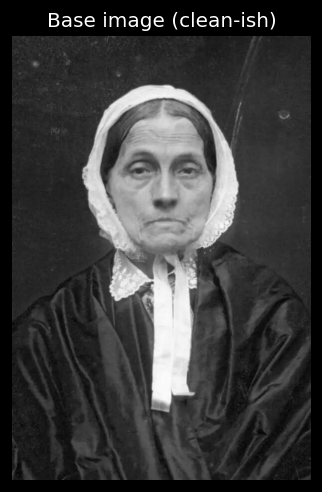

Saved figs/clean_base.png


In [3]:

IMG_PATH = "photos/old_photo_01.jpg"  # change as needed
#IMG_PATH = "../62-216.jpg"  # change as needed

img_bgr = cv.imread(IMG_PATH, cv.IMREAD_COLOR)

if img_bgr is None:
    # Fallback: simple synthetic base (so the lab always runs)
    h, w = 512, 384
    img = np.full((h, w), 120, dtype=np.uint8)
    cv.circle(img, (w//2, h//2-40), 120, 140, -1)                # face
    cv.circle(img, (w//2-45, h//2-70), 20, 80, -1)               # left eye
    cv.circle(img, (w//2+45, h//2-70), 20, 80, -1)               # right eye
    cv.ellipse(img, (w//2, h//2+10), (50, 30), 0, 0, 180, 90, 4) # smile
    cv.putText(img, "1912", (20, h-25), cv.FONT_HERSHEY_SIMPLEX, 1.2, 90, 2, cv.LINE_AA)
    img_gray_clean = img
    print("Loaded fallback synthetic base image (old_photo_input.jpg not found).")
else:
    img_gray_clean = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)
    print("Loaded:", IMG_PATH)

gt = img_gray_clean           #Ground Truth Image
show(img_gray_clean, "Base image (clean-ish)")
save_u8("figs/clean_base.png", img_gray_clean)


## Create synthetic degradation (dust, scratches, fading, grain)

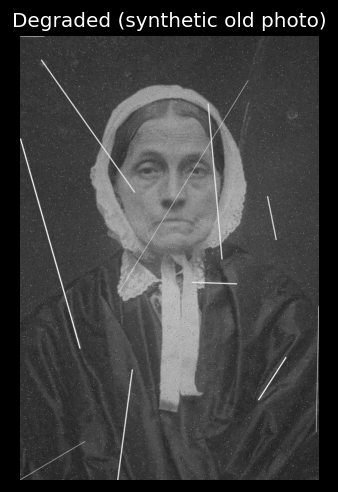

Saved figs/degraded.png


In [4]:

rng = np.random.default_rng(0)

def add_fading(img, strength=0.35):
    imgf = img.astype(np.float32)
    imgf = imgf * (1.0 - strength) + 128 * strength
    h, w = img.shape
    yy, xx = np.mgrid[0:h, 0:w]
    cy, cx = h/2, w/2
    r = np.sqrt((yy-cy)**2 + (xx-cx)**2) / np.sqrt(cy**2 + cx**2)
    vign = 1.0 - 0.25 * r
    imgf = imgf * vign
    return np.clip(imgf, 0, 255).astype(np.uint8)

def add_dust(img, p=0.006):
    out = img.copy()
    mask = rng.random(img.shape) < p
    out[mask] = rng.choice([0, 255], size=mask.sum()).astype(np.uint8)
    return out

def add_scratches(img, n_lines=16):
    out = img.copy()
    h, w = img.shape
    for _ in range(n_lines):
        x1 = int(rng.integers(0, w))
        y1 = int(rng.integers(0, h))
        x2 = int(np.clip(x1 + rng.integers(-w//2, w//2), 0, w-1))
        y2 = int(np.clip(y1 + rng.integers(-h//2, h//2), 0, h-1))
        thickness = int(rng.integers(1, 3))
        color = int(rng.integers(210, 255))  # bright scratch
        cv.line(out, (x1, y1), (x2, y2), color, thickness, cv.LINE_AA)
    return out

def add_grain(img, sigma=9.0):
    n = rng.normal(0, sigma, img.shape).astype(np.float32)
    out = np.clip(img.astype(np.float32) + n, 0, 255).astype(np.uint8)
    return out

img_deg = img_gray_clean.copy()
img_deg = add_fading(img_deg, strength=0.35)
img_deg = add_grain(img_deg, sigma=9.0)
img_deg = add_dust(img_deg, p=0.006)
img_deg = add_scratches(img_deg, n_lines=11)

show(img_deg, "Degraded (synthetic old photo)")
save_u8("figs/degraded.png", img_deg)


### DFT magnitude

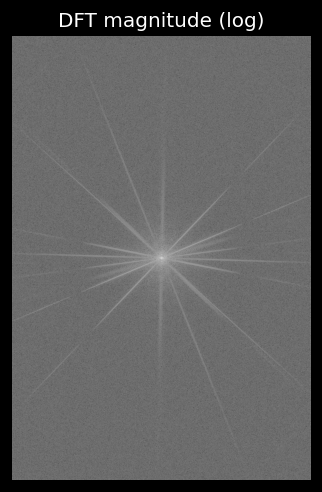

Saved figs/dft_magnitude.png


In [5]:
#img_deg = img_gray_clean
F = np.fft.fft2(img_deg)
Fshift = np.fft.fftshift(F)
mag = np.log(np.abs(Fshift) + 1.0)
mag_u8 = (255 * (mag - mag.min()) / (mag.max() - mag.min() + 1e-12)).astype(np.uint8)

show(mag_u8, "DFT magnitude (log)")
save_u8("figs/dft_magnitude.png", mag_u8)


## Gaussian smoothing (choose $\sigma$ or a range of $\sigma$ values)

#### Note:  You need to pick one value for `sigma_choice` that will be used in later steps.

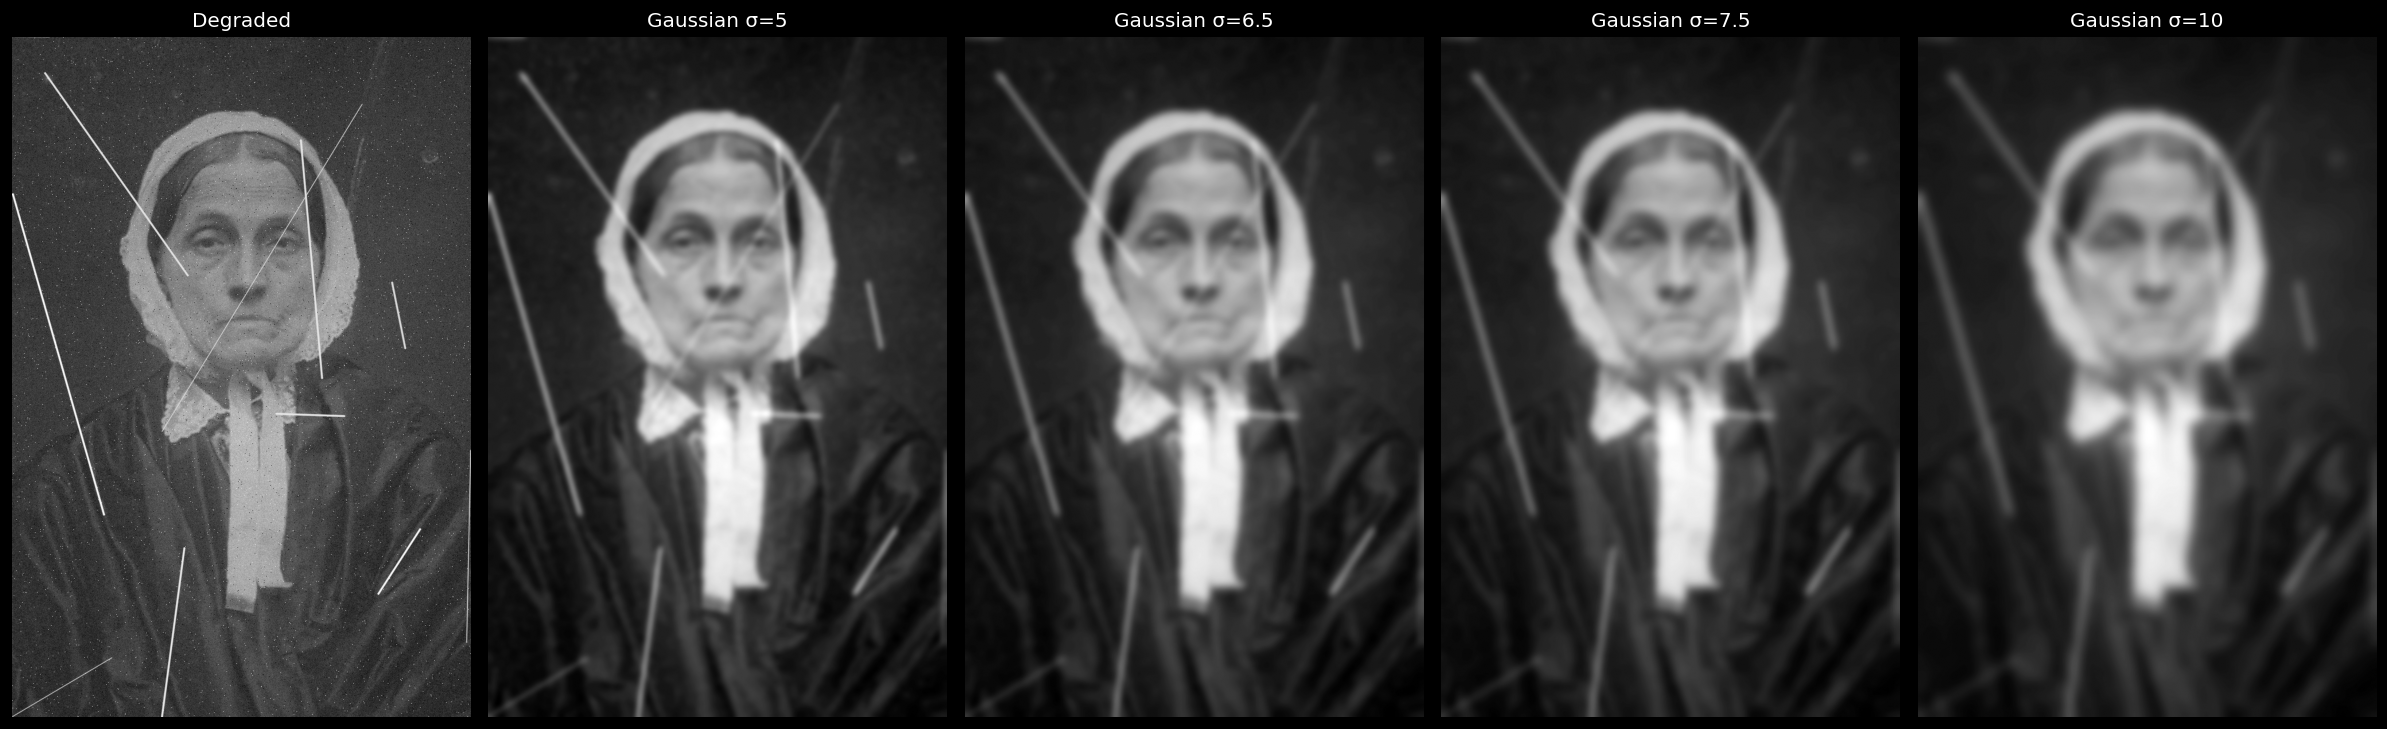

Saved figs/gaussian_example.png


In [6]:

sigmas = [5, 6.5, 7.5, 10]   # Put in your value(s) for sigma here - can be a list.
blurs = [cv.GaussianBlur(img_deg, (0,0), s, s) for s in sigmas]

plt.figure(figsize=(20,6))
plt.subplot(1, len(sigmas)+1, 1); plt.imshow(img_deg, cmap="gray"); plt.title("Degraded"); plt.axis("off")
for i, s in enumerate(sigmas):
    plt.subplot(1, len(sigmas)+1, i+2); plt.imshow(blurs[i], cmap="gray"); plt.title(f"Gaussian σ={s}"); plt.axis("off")
plt.tight_layout(); plt.show()

save_u8("figs/gaussian_example.png", np.hstack([blurs[0], blurs[-1]]))

# Pick one sigma for later steps
sigma_choice = 5
img_s = cv.GaussianBlur(img_deg, (0,0), sigma_choice, sigma_choice)


## Gradients (Sobel)

The code below finds the gradient vector using a Sobel filter.  The default value for the kernel size is `ksize=3`.  The commonly used values are `k=1,3,5,7` with `k=-1` producing a Scharr filter.

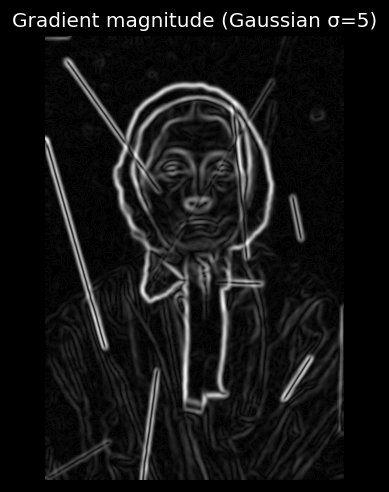

Saved figs/gradient_example.png


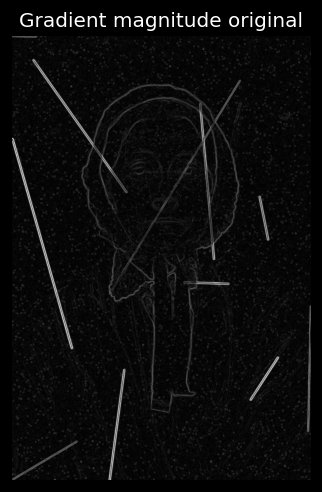

Saved figs/gradient_exampleORIG.png


In [7]:
ksize = 3      #Pick the kernel size - the defaul is 3
gx = cv.Sobel(img_s, cv.CV_64F, 1, 0, ksize=ksize)
gy = cv.Sobel(img_s, cv.CV_64F, 0, 1, ksize=ksize)
gmag = np.sqrt(gx*gx + gy*gy)
gmag_u8 = cv.normalize(gmag, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

show(gmag_u8, f"Gradient magnitude (Gaussian σ={sigma_choice})")
save_u8("figs/gradient_example.png", gmag_u8)

ksize = 7      #Pick the kernel size - the defaul is 3
gx = cv.Sobel(img_deg, cv.CV_64F, 1, 0, ksize=ksize)
gy = cv.Sobel(img_deg, cv.CV_64F, 0, 1, ksize=ksize)
gmag = np.sqrt(gx*gx + gy*gy)
gmag_u8 = cv.normalize(gmag, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

show(gmag_u8, f"Gradient magnitude original")
save_u8("figs/gradient_exampleORIG.png", gmag_u8)



## Median filtering (dust)

In OpenCV, the median filter size `k` must be specified.  The filter size must be odd and greater than 3.  The most common values for `k` are 3,5,7.

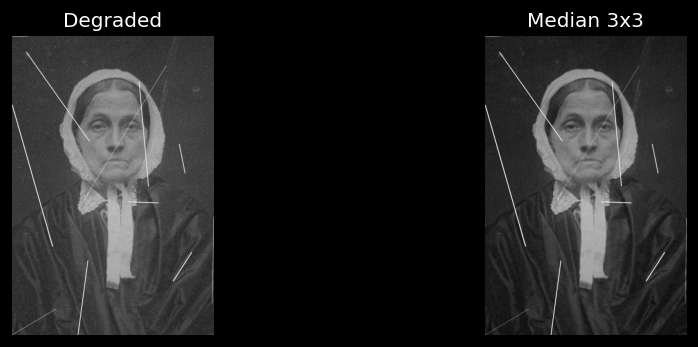

Saved figs/median_example.png


In [9]:
ksize= 3      #Pick the size of the median filter
med5 = cv.medianBlur(img_deg, ksize=ksize)

plt.figure(figsize=(10,3))
plt.subplot(1,2,1); plt.imshow(img_deg, cmap="gray"); plt.title("Degraded"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(med5, cmap="gray"); plt.title(f"Median {ksize}x{ksize}"); plt.axis("off")
plt.tight_layout(); plt.show()

save_u8("figs/median_example.png", np.hstack([img_deg, med5]))


## Morphology (Mask Refinement + Morph Gradient)

Here, the input is the gradient magnitude image. Read the write-up for other options for the input as well as the structuring element that is used.

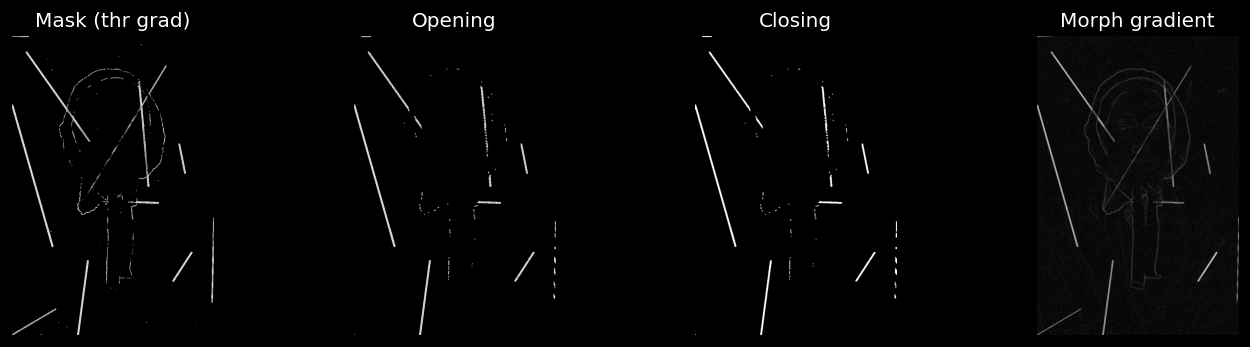

Saved figs/morph_example.png


In [15]:

thr = int(0.25 * gmag_u8.max())                               # Pick your threshold
_, mask = cv.threshold(gmag_u8, thr, 255, cv.THRESH_BINARY)   # Gradient magnitued

kernel = cv.getStructuringElement(cv.MORPH_RECT, (3,3))    #Define your structuring element and size
mask_open = cv.morphologyEx(mask, cv.MORPH_OPEN, kernel, iterations=1)
mask_close = cv.morphologyEx(mask_open, cv.MORPH_CLOSE, kernel, iterations=2)

# Morph gradient on median-filtered image
dil = cv.dilate(med5, kernel, iterations=1)
ero = cv.erode(med5, kernel, iterations=1)
mgrad = cv.subtract(dil, ero)

plt.figure(figsize=(12,3))
plt.subplot(1,4,1); plt.imshow(mask, cmap="gray"); plt.title("Mask (thr grad)"); plt.axis("off")
plt.subplot(1,4,2); plt.imshow(mask_open, cmap="gray"); plt.title("Opening"); plt.axis("off")
plt.subplot(1,4,3); plt.imshow(mask_close, cmap="gray"); plt.title("Closing"); plt.axis("off")
plt.subplot(1,4,4); plt.imshow(mgrad, cmap="gray"); plt.title("Morph gradient"); plt.axis("off")
plt.tight_layout(); plt.show()

save_u8("figs/morph_example.png", np.hstack([mask, mask_close, mgrad]))


## Optional inpainting + CLAHE (final output)

***Note***:  You probably want to experiment with the inpaint radius, along with the CLAHE hyperparameters.

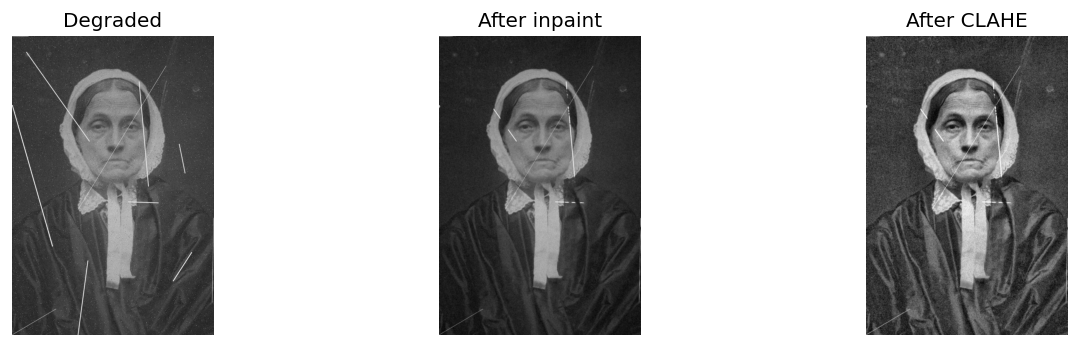

Saved figs/final_restored.png


In [152]:

inpaint_radius = 3
rest_inpaint = cv.inpaint(med5, mask_close, inpaint_radius, cv.INPAINT_TELEA)

clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
rest_final = clahe.apply(rest_inpaint)

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); plt.imshow(img_deg, cmap="gray"); plt.title("Degraded"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(rest_inpaint, cmap="gray"); plt.title("After inpaint"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(rest_final, cmap="gray"); plt.title("After CLAHE"); plt.axis("off")
plt.tight_layout(); plt.show()

save_u8("figs/final_restored.png", rest_final)


## Quantitative evaluation (synthetic ground truth)

### PSNR

In [153]:
def psnr(a, b):
    a = a.astype(np.float32)
    b = b.astype(np.float32)
    mse = np.mean((a-b)**2)
    if mse == 0:
        return float("inf")
    return 10*np.log10((255**2)/mse)

print("PSNR(degraded vs clean):", psnr(img_deg, img_gray_clean))
print("PSNR(restored vs clean):", psnr(rest_final, img_gray_clean))


PSNR(degraded vs clean): 18.253595
PSNR(restored vs clean): 17.979076


### Grain Proxy

In [154]:
img_in = img_deg
img_out = rest_final
gt = img_gray_clean
def grain_proxy_std(img_u8, sigma=2.0):
    x = img_u8.astype(np.float32) / 255.0
    low = cv.GaussianBlur(x, (0,0), sigmaX=sigma, sigmaY=sigma)
    r = x - low
    return float(r.std()), r  # std in [0..1] scale

g_in, r_in = grain_proxy_std(img_in, sigma=2.0)
g_out, r_out = grain_proxy_std(img_out, sigma=2.0)
print("Grain proxy std (in,out):", g_in, g_out)

Grain proxy std (in,out): 0.06213859096169472 0.03586793690919876


### Edge Density

In [155]:
def edge_density_canny(img_u8, t1=50, t2=150, blur=1.0):
    x = img_u8
    if blur and blur > 0:
        x = cv.GaussianBlur(x, (0,0), blur)
    e = cv.Canny(x, t1, t2)
    dens = float((e > 0).mean())
    return dens, e

d_in, e_in = edge_density_canny(img_in)
d_out, e_out = edge_density_canny(img_out)
print("Edge density (in,out):", d_in, d_out)

Edge density (in,out): 0.019994734625105308 0.026315290648694187


### Structural Similarity Indes (SSIM)

SSIM: 0.4946095895478978


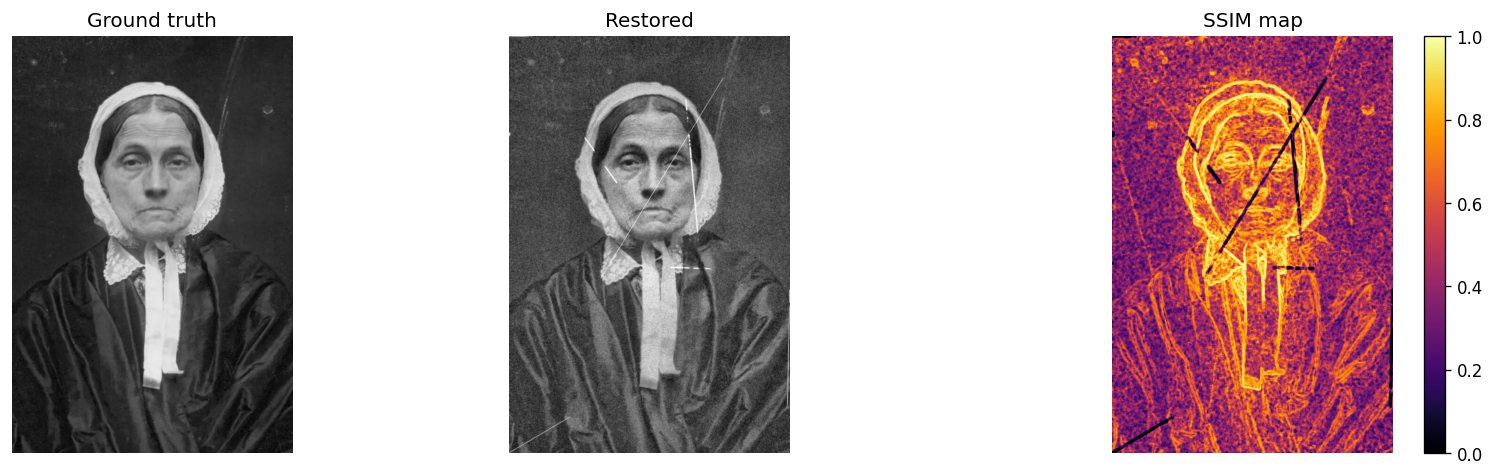

In [156]:
# SSIM (requires scikit-image)
try:
    from skimage.metrics import structural_similarity as ssim
except Exception:
    ssim = None

if gt is not None:
    if ssim is not None:
        print("SSIM:", float(ssim(gt, img_out, data_range=255)))
    else:
        print("SSIM not available (pip install scikit-image).")

score, ssim_map = ssim(gt, img_out, data_range=255, full=True)

plt.figure(figsize=(14,4))

plt.subplot(1,3,1)
plt.imshow(gt, cmap="gray", vmin=0, vmax=255)
plt.title("Ground truth")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(img_out, cmap="gray", vmin=0, vmax=255)
plt.title("Restored")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(ssim_map, cmap="inferno", vmin=0, vmax=1)
plt.title("SSIM map")
plt.axis("off")
plt.colorbar(fraction=0.046)

plt.tight_layout()
plt.show()


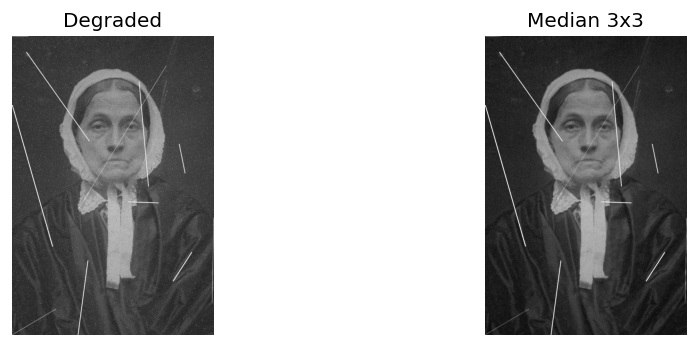

Saved figs/median_example.png


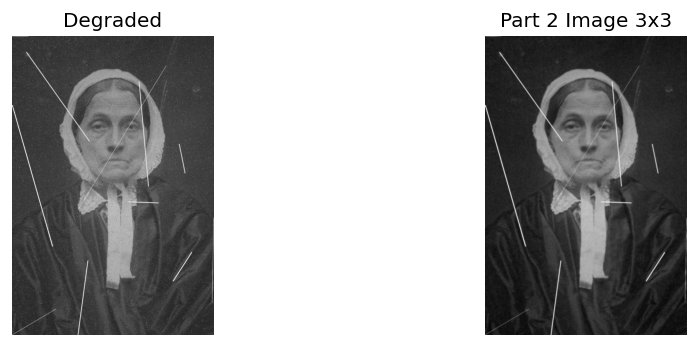

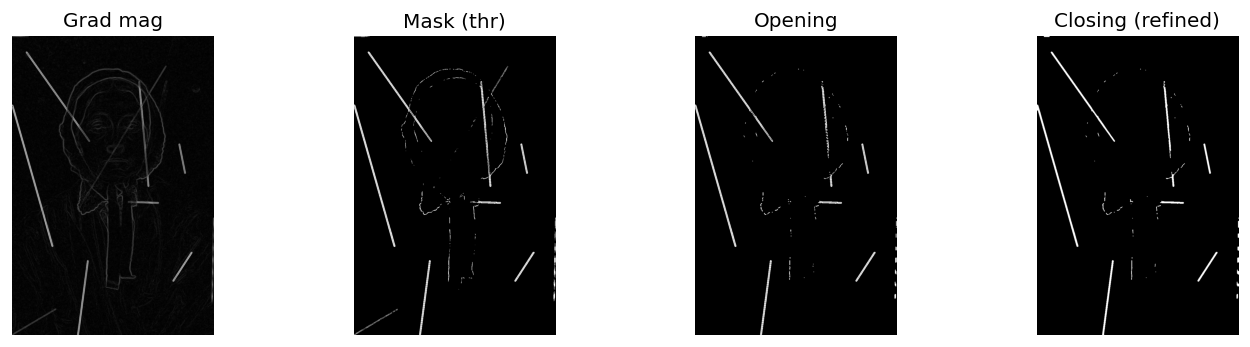

Saved figs/mask_refinement.png


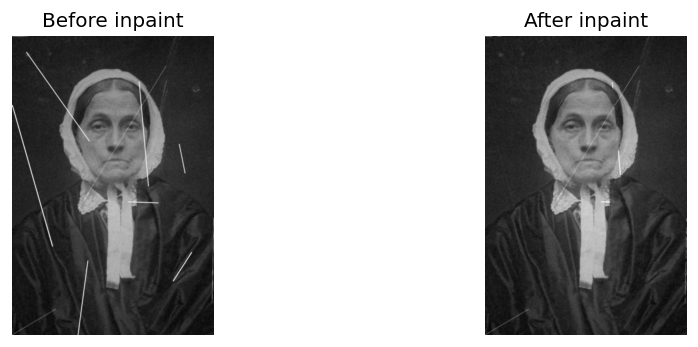

Saved figs/inpaint_example.png


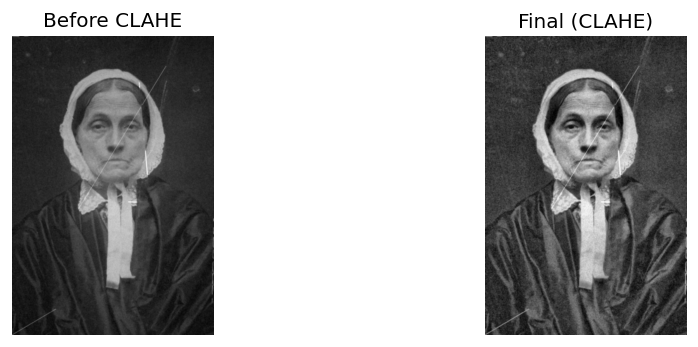

Saved figs/final_restored.png
PSNR (degraded vs clean): 18.253595
PSNR (restored vs clean): 18.900797
Grain proxy std (before, after): 0.06213859096169472 0.01895005814731121
Edge density (before, after): 0.019994734625105308 0.01264111204717776


In [178]:
#PipeLine []
ksize= 3      #Pick the size of the median filter
med = cv.medianBlur(img_deg, ksize=ksize)

plt.figure(figsize=(10,3))
plt.subplot(1,2,1); plt.imshow(img_deg, cmap="gray"); plt.title("Degraded"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(med, cmap="gray"); plt.title(f"Median {ksize}x{ksize}"); plt.axis("off")
plt.tight_layout(); plt.show()

save_u8("figs/median_example.png", np.hstack([img_deg, med5]))

sigma_choice = 1

image_step2 = cv.GaussianBlur(med, (0,0), sigma_choice, sigma_choice)

plt.figure(figsize=(10,3))
plt.subplot(1,2,1); plt.imshow(img_deg, cmap="gray"); plt.title("Degraded"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(image_step2, cmap="gray"); plt.title(f"Part 2 Image {ksize}x{ksize}"); plt.axis("off")
plt.tight_layout(); plt.show()

ksize_sobel = 3  # keep 3 for smoothed image (you already decided this earlier)

gx = cv.Sobel(image_step2, cv.CV_64F, 1, 0, ksize=ksize_sobel)
gy = cv.Sobel(image_step2, cv.CV_64F, 0, 1, ksize=ksize_sobel)
gmag = np.sqrt(gx*gx + gy*gy)
gmag_u8 = cv.normalize(gmag, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

thr = int(0.25 * gmag_u8.max())  # you can tune: 0.2–0.35 often
_, mask = cv.threshold(gmag_u8, thr, 255, cv.THRESH_BINARY)

# Try two structuring elements
k_small = cv.getStructuringElement(cv.MORPH_ELLIPSE, (3,3))
k_big   = cv.getStructuringElement(cv.MORPH_RECT, (7,7))

mask_open = cv.morphologyEx(mask, cv.MORPH_OPEN, k_small, iterations=1)
mask_ref  = cv.morphologyEx(mask_open, cv.MORPH_CLOSE, k_big, iterations=1)

plt.figure(figsize=(12,3))
plt.subplot(1,4,1); plt.imshow(gmag_u8, cmap="gray"); plt.title("Grad mag"); plt.axis("off")
plt.subplot(1,4,2); plt.imshow(mask, cmap="gray"); plt.title("Mask (thr)"); plt.axis("off")
plt.subplot(1,4,3); plt.imshow(mask_open, cmap="gray"); plt.title("Opening"); plt.axis("off")
plt.subplot(1,4,4); plt.imshow(mask_ref, cmap="gray"); plt.title("Closing (refined)"); plt.axis("off")
plt.tight_layout(); plt.show()

save_u8("figs/mask_refinement.png", np.hstack([gmag_u8, mask, mask_ref]))

# -----------------------
# Step 4: Inpainting (removes scratches where mask=255)
# -----------------------
radius = 3
img_inpaint = cv.inpaint(image_step2, mask_ref, radius, cv.INPAINT_TELEA)

plt.figure(figsize=(10,3))
plt.subplot(1,2,1); plt.imshow(image_step2, cmap="gray"); plt.title("Before inpaint"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(img_inpaint, cmap="gray"); plt.title("After inpaint"); plt.axis("off")
plt.tight_layout(); plt.show()

save_u8("figs/inpaint_example.png", np.hstack([image_step2, img_inpaint]))

# -----------------------
# Step 5: CLAHE (final contrast enhancement)
# -----------------------
clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
img_final = clahe.apply(img_inpaint)

plt.figure(figsize=(10,3))
plt.subplot(1,2,1); plt.imshow(img_inpaint, cmap="gray"); plt.title("Before CLAHE"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(img_final, cmap="gray"); plt.title("Final (CLAHE)"); plt.axis("off")
plt.tight_layout(); plt.show()

save_u8("figs/final_restored.png", img_final)

#Metric 1
def psnr(a, b):
    a = a.astype(np.float32)
    b = b.astype(np.float32)
    mse = np.mean((a - b) ** 2)
    if mse == 0:
        return float("inf")
    return 10 * np.log10((255**2) / mse)

print("PSNR (degraded vs clean):", psnr(img_deg, img_gray_clean))
print("PSNR (restored vs clean):", psnr(img_final, img_gray_clean))
#Metric 2
def grain_proxy_std(img_u8, sigma=2.0):
    x = img_u8.astype(np.float32) / 255.0
    low = cv.GaussianBlur(x, (0,0), sigmaX=sigma, sigmaY=sigma)
    r = x - low
    return float(r.std()), r

g_in, r_in = grain_proxy_std(img_deg, sigma=2.0)
g_out, r_out = grain_proxy_std(img_final, sigma=2.0)

print("Grain proxy std (before, after):", g_in, g_out)
#Metric 3
def edge_density_canny(img_u8, t1=50, t2=150, blur=1.0):
    x = img_u8
    if blur and blur > 0:
        x = cv.GaussianBlur(x, (0,0), blur)
    e = cv.Canny(x, t1, t2)
    dens = float((e > 0).mean())
    return dens, e

d_in, e_in = edge_density_canny(img_deg)
d_out, e_out = edge_density_canny(img_final)

print("Edge density (before, after):", d_in, d_out)







